# Challenge 2: Image Classification

## Hyperparameters

In [35]:
# --- Stochasticity -- 
SEED = 200

VALIDATION_SIZE = 0.2
IMAGE_SIZE = 64
INPUT_SIZE = 64


# --- Model Parameters ---
MODEL_TYPE = 'ResNet18'
PRETRAINED = True
NUM_CLASSES = 4

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
EPOCHS = 300
PATIENCE = 20
OPTIMIZER = 'AdamW'

# Regularisation
DROPOUT_RATE = 0.2       
L1_LAMBDA = 0             
L2_LAMBDA = 0            

# Plot config
PLOT_FLAG = True

# --- Data Settings ---
WHITELIST_PATH = 'whitelist/clean_train_data.txt'

TRAIN_DATA_PATH = 'train_data'
TRAIN_IMAGES_CACHE_PATH = 'cache/train_images_cache.npy'
TRAIN_MASKS_CACHE_PATH = 'cache/train_masks_cache.npy'
TRAIN_MASKED_IMAGES_CACHE_PATH = 'cache/train_masked_images_cache.npy' 
TRAIN_LABEL_PATH = 'train_labels.csv'

TEST_DATA_PATH = 'test_data'
TEST_IMAGE_CACHE_PATH  = 'cache/test_images_cache.npy'
TEST_MASKS_CACHE_PATH = 'cache/test_masks_cache.npy'
TEST_MASKED_IMAGES_CACHE_PATH = 'cache/test_masked_images_cache.npy' 




## Module imports

In [36]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.cm as cm  
import random
import math




if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")




PyTorch version: 2.9.1+cu130
Device: cuda


## Image and Label Loader

In [37]:
def get_whitelisted_ids(whitelist_path):
    if not whitelist_path or not os.path.exists(whitelist_path):
        return None
    ids = set()
    with open(whitelist_path, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split('_')
                if len(parts) > 1:
                    ids.add(parts[1].split('.')[0])
    return sorted(list(ids), key=int)


In [38]:
def load_labels_aligned(csv_path, filtered_ids_list):
    print(f"Loading labels for {len(filtered_ids_list)} filtered images...")
    df = pd.read_csv(csv_path)
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(lambda x: x.split('_')[1].split('.')[0] if '_' in x else x)
    label_map = dict(zip(df['clean_id'], df[label_col]))
    
    final_labels = []
    for uid in filtered_ids_list:
        if uid in label_map:
            final_labels.append(label_map[uid])
        else:
            raise ValueError(f"Label missing for ID {uid}")
    return np.array(final_labels)

In [39]:
# %%
# --- MULTI-PATCH SAMPLING (ResNet20 Strategy: Native Resolution) ---
MAX_PATCHES_PER_IMAGE = 3

def load_and_process_pipeline_multi_patch_balanced(folder, label_path, cache_paths, whitelist_path=None, target_size=224):
    path_raw, path_mask, path_masked = cache_paths
    
    # 1. Identify IDs
    all_files = [f for f in os.listdir(folder) if f.startswith("img_") and f.endswith(".png")]
    available_ids = set(f.split('_')[1].split('.')[0] for f in all_files)
    
    if whitelist_path and os.path.exists(whitelist_path):
        target_ids = get_whitelisted_ids(whitelist_path)
        final_ids = list(available_ids.intersection(target_ids))
    else:
        final_ids = list(available_ids)
    
    final_ids = sorted(final_ids, key=int)

    # 2. Calculate Balancing
    print("Calculating class balancing weights...")
    df = pd.read_csv(label_path)
    id_col = df.columns[0]; label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(lambda x: x.split('_')[1].split('.')[0] if '_' in x else x)
    df_filtered = df[df['clean_id'].isin(final_ids)]
    id_to_label = dict(zip(df_filtered['clean_id'], df_filtered[label_col]))
    
    class_counts = df_filtered[label_col].value_counts().to_dict()
    max_count = max(class_counts.values())
    BASE_PATCHES = 2 
    patch_limits = {}
    for cls, count in class_counts.items():
        ratio = max_count / count
        limit = math.ceil(BASE_PATCHES * ratio)
        patch_limits[cls] = min(limit, 12) 
        
    print(f"Cache will be generated. Processing {len(final_ids)} images...")
    
    all_raw_patches = []
    all_mask_patches = []
    all_masked_patches = []
    all_patch_image_ids = []

    for image_id in final_ids:
        img_path = os.path.join(folder, f"img_{image_id}.png")
        mask_path = os.path.join(folder, f"mask_{image_id}.png")
        if not os.path.exists(mask_path): continue
            
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        mask_single_channel = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img_h, img_w = img.shape[:2]
        
        # --- BLOB DETECTION ---
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_single_channel, 8, cv2.CV_32S)
        
        # Sort blobs by area (Largest first)
        blob_areas = []
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            blob_areas.append((i, area))
        blob_areas.sort(key=lambda x: x[1], reverse=True)
        sorted_labels = [x[0] for x in blob_areas]
        
        current_label = id_to_label.get(image_id)
        max_patches = patch_limits.get(current_label, BASE_PATCHES)
        selected_labels = sorted_labels[:max_patches]

        # Prepare Padding to allow cropping near edges
        pad = target_size // 2
        img_padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT_101)
        mask_rgb_padded = cv2.copyMakeBorder(mask_rgb, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])

        for label_idx in selected_labels:
            # 1. Create mask for this blob
            instance_mask = np.zeros_like(mask_single_channel)
            instance_mask[labels == label_idx] = 255
            
            # 2. Find Center (Pole of Inaccessibility)
            dist_img = cv2.distanceTransform(instance_mask, cv2.DIST_L2, 5)
            _, _, _, max_loc = cv2.minMaxLoc(dist_img)
            center_x, center_y = max_loc
            
            # 3. Adjust for padding
            cx_pad = center_x + pad
            cy_pad = center_y + pad
            
            # 4. FIXED CROP (Native Resolution) - NO RESIZING
            y1 = cy_pad - target_size // 2
            y2 = cy_pad + target_size // 2
            x1 = cx_pad - target_size // 2
            x2 = cx_pad + target_size // 2
            
            raw_patch = img_padded[y1:y2, x1:x2]
            mask_rgb_patch = mask_rgb_padded[y1:y2, x1:x2]

            all_raw_patches.append(raw_patch)
            all_mask_patches.append(mask_rgb_patch)
            all_masked_patches.append(raw_patch) # Standard RGB input
            all_patch_image_ids.append(image_id)

    # Save cache
    X_raw = np.array(all_raw_patches, dtype=np.uint8)
    X_mask = np.array(all_mask_patches, dtype=np.uint8)
    X_masked = np.array(all_masked_patches, dtype=np.uint8)
    
    os.makedirs(os.path.dirname(path_raw), exist_ok=True)
    np.save(path_raw, X_raw)
    np.save(path_mask, X_mask)
    np.save(path_masked, X_masked)
    
    print(f"Processed cache saved. Total Patches: {len(all_raw_patches)}")
    return X_raw, X_mask, X_masked, all_patch_image_ids

# Standard Loader (Test) - Similar logic but no balancing
def load_and_process_pipeline_multi_patch(folder, cache_paths, whitelist_path=None, target_size=224):
    path_raw, path_mask, path_masked = cache_paths
    
    all_files = [f for f in os.listdir(folder) if f.startswith("img_") and f.endswith(".png")]
    available_ids = set(f.split('_')[1].split('.')[0] for f in all_files)
    final_ids = sorted(list(available_ids), key=int)
    
    if os.path.exists(path_raw) and os.path.exists(path_mask):
         print(f"Loading PROCESSED cache from disk ({folder})...")
         X_raw = np.load(path_raw); X_mask = np.load(path_mask); X_masked = np.load(path_masked)
         if len(X_raw) > 0: return X_raw, X_mask, X_masked, [str(i) for i in range(len(X_raw))]

    print(f"Processing Test Pipeline (Standard)...")
    all_raw, all_mask, all_masked, all_ids = [], [], [], []
    
    for image_id in final_ids:
        img_path = os.path.join(folder, f"img_{image_id}.png")
        mask_path = os.path.join(folder, f"mask_{image_id}.png")
        if not os.path.exists(mask_path): continue
            
        img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path); mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_gray, 8, cv2.CV_32S)
        valid_labels = list(range(1, num_labels))
        # Limit test patches
        if len(valid_labels) > 3: valid_labels = random.sample(valid_labels, 3)
        
        pad = target_size // 2
        img_p = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT_101)
        mask_p = cv2.copyMakeBorder(mask_rgb, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])
        
        for label_idx in valid_labels:
            inst_mask = np.zeros_like(mask_gray); inst_mask[labels == label_idx] = 255
            dist = cv2.distanceTransform(inst_mask, cv2.DIST_L2, 5)
            _, _, _, (cx, cy) = cv2.minMaxLoc(dist)
            
            y1, y2 = (cy+pad)-target_size//2, (cy+pad)+target_size//2
            x1, x2 = (cx+pad)-target_size//2, (cx+pad)+target_size//2
            
            all_raw.append(img_p[y1:y2, x1:x2])
            all_mask.append(mask_p[y1:y2, x1:x2])
            all_masked.append(img_p[y1:y2, x1:x2])
            all_ids.append(image_id)
            
    X_raw = np.array(all_raw, dtype=np.uint8); X_mask = np.array(all_mask, dtype=np.uint8); X_masked = np.array(all_masked, dtype=np.uint8)
    np.save(path_raw, X_raw); np.save(path_mask, X_mask); np.save(path_masked, X_masked)
    return X_raw, X_mask, X_masked, all_ids

In [40]:
def get_sorted_filenames(folder):
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"): ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids), key=int)]

## Dataloader creation

In [41]:
from torch.utils.data import Dataset

# ---------------------------------------------------------
# IMAGE-LEVEL MIL DATASET: EACH SAMPLE = BAG OF PATCHES
# ---------------------------------------------------------
class ImageBagDataset(Dataset):
    """
    Each item is:
      - patches: Tensor of shape (N_PATCHES_PER_IMAGE, C, H, W), values in [0, 1]
      - label:   int (encoded class)
    """
    def __init__(self, 
                 X_patches_tensor,      # (N_total_patches, C, H, W), float32 in [0, 1]
                 patch_image_ids,       # np.array of image IDs per patch (strings or ints)
                 image_id_list,         # list/array of unique image IDs for this split
                 label_map,             # dict: image_id (str) -> label string
                 label_encoder,         # fitted sklearn LabelEncoder
                 n_patches_per_image=8  # fixed number of patches per image
                 ):
        super().__init__()
        self.X = X_patches_tensor
        self.patch_image_ids = np.array(patch_image_ids)
        self.image_ids = list(image_id_list)
        self.label_map = label_map
        self.le = label_encoder
        self.n_patches = n_patches_per_image

        # Precompute indices of patches for each image_id
        self.indices_per_image = {}
        for uid in self.image_ids:
            idxs = np.where(self.patch_image_ids == uid)[0]
            if len(idxs) == 0:
                raise ValueError(f"No patches found for image ID {uid} in MIL dataset.")
            self.indices_per_image[uid] = idxs

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        uid = self.image_ids[idx]
        patch_idxs = self.indices_per_image[uid]

        # Sample a fixed number of patches per image (with replacement if needed)
        if len(patch_idxs) >= self.n_patches:
            chosen = np.random.choice(patch_idxs, self.n_patches, replace=False)
        else:
            chosen = np.random.choice(patch_idxs, self.n_patches, replace=True)

        patches = self.X[chosen]  # (N_PATCHES_PER_IMAGE, C, H, W), still on CPU here

        label_str = self.label_map[uid]
        label_int = self.le.transform([label_str])[0]  # single int

        return patches, label_int


Calculating class balancing weights...
Cache will be generated. Processing 581 images...
Processed cache saved. Total Patches: 1653
Processing Test Pipeline (Standard)...
Loading labels for 581 filtered images...
Preprocessing Training Data...
Stats (0-1 Range): Min=0.00, Max=0.96
Preprocessing Test Data...
Stats (0-1 Range): Min=0.00, Max=0.95
------------------------------
Total Unique Images: 581
Train Patches: 1315 | Val Patches: 338
Test Patches:  1375
------------------------------


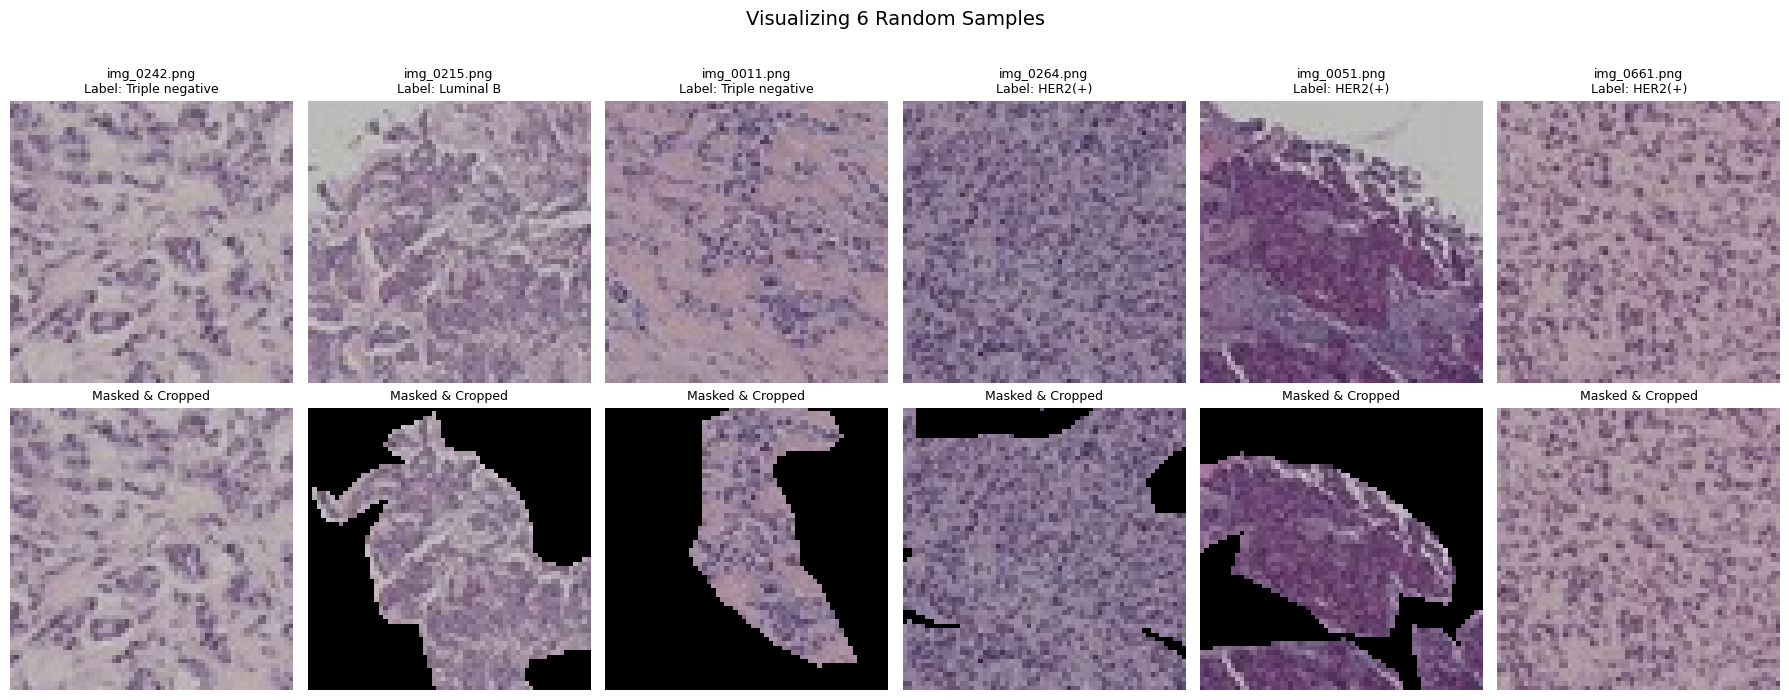

In [42]:
# %%
# --- DATA LOADING BLOCK (All in One) ---

def make_loader(ds, batch_size, shuffle, drop_last):
    # Robust worker detection
    if os.name == 'nt': num = 0 
    else: num = min(8, os.cpu_count() or 2)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num, pin_memory=True)

def preprocess_inputs(images):
    # Input: (N, H, W, 3) uint8
    # Output: (N, 3, H, W) float32, 0-1 range
    tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)
    tensor = tensor / 255.0 
    print(f"Stats (0-1 Range): Min={tensor.min():.2f}, Max={tensor.max():.2f}")
    return tensor

# 1. Load Training Data (Balanced Multi-Patch)
train_cache = ('cache/train_img_bal.npy', 'cache/train_msk_bal.npy', 'cache/train_mkd_bal.npy')
raw_train, train_masks, train_images_masked, train_ids_patches = load_and_process_pipeline_multi_patch_balanced(
    TRAIN_DATA_PATH, TRAIN_LABEL_PATH, train_cache, WHITELIST_PATH, IMAGE_SIZE)

# 2. Load Test Data (Standard Multi-Patch - No Labels)
test_cache = ('cache/test_img_std.npy', 'cache/test_msk_std.npy', 'cache/test_mkd_std.npy')
raw_test, test_masks, test_images_masked, test_ids_patches = load_and_process_pipeline_multi_patch(
    TEST_DATA_PATH, test_cache, None, IMAGE_SIZE)

# 3. Process Training Labels
unique_train_ids = sorted(list(set(train_ids_patches)), key=int)
original_labels = load_labels_aligned(TRAIN_LABEL_PATH, unique_train_ids)
label_map = dict(zip(unique_train_ids, original_labels))
train_labels_multi = np.array([label_map[uid] for uid in train_ids_patches])

# 4. Create Tensors
print("Preprocessing Training Data...")
X_tensor = preprocess_inputs(train_images_masked)

print("Preprocessing Test Data...")
X_test_tensor = preprocess_inputs(test_images_masked)

# Encode Labels
label_encoder = LabelEncoder()
label_encoder.fit(original_labels)
y_encoded = label_encoder.transform(train_labels_multi)
Y_tensor = torch.from_numpy(y_encoded).long()

# 5. Split (Leakage-Proof: Split by Image ID, not Patch ID)
patch_to_id = np.array(train_ids_patches)
unique_ids = np.unique(patch_to_id)

# Stratify based on the label of the unique image
train_ids_split, val_ids_split = train_test_split(
    unique_ids, 
    test_size=VALIDATION_SIZE, 
    random_state=SEED, 
    stratify=[label_map[uid] for uid in unique_ids]
)

# Create boolean masks for patches
train_mask = np.isin(patch_to_id, train_ids_split)
val_mask = np.isin(patch_to_id, val_ids_split)

# Create Datasets
train_ds = TensorDataset(X_tensor[train_mask], Y_tensor[train_mask])
val_ds   = TensorDataset(X_tensor[val_mask],   Y_tensor[val_mask])
test_ds  = TensorDataset(X_test_tensor)

# ---------------------------------------------------------
# IMAGE-LEVEL MIL DATALOADERS
# ---------------------------------------------------------
N_PATCHES_PER_IMAGE = 8  # you can tune this (e.g., 4, 8, 12)

# Train / Val image lists (these are image IDs, not patch IDs)
train_image_ids = train_ids_split  # already stratified split by image ID
val_image_ids   = val_ids_split

# MIL Datasets: each sample is a bag of patches for one image
train_mil_ds = ImageBagDataset(
    X_patches_tensor=X_tensor,          # (N_patches, C, H, W) in [0,1]
    patch_image_ids=patch_to_id,        # one image ID per patch
    image_id_list=train_image_ids,      # list of train image IDs
    label_map=label_map,                # image_id -> label string
    label_encoder=label_encoder,
    n_patches_per_image=N_PATCHES_PER_IMAGE
)

val_mil_ds = ImageBagDataset(
    X_patches_tensor=X_tensor,
    patch_image_ids=patch_to_id,
    image_id_list=val_image_ids,
    label_map=label_map,
    label_encoder=label_encoder,
    n_patches_per_image=N_PATCHES_PER_IMAGE
)

# Use your existing make_loader helper
train_loader_mil = make_loader(train_mil_ds, BATCH_SIZE, True, False)
val_loader_mil   = make_loader(val_mil_ds,   BATCH_SIZE, False, False)


# 6. Cleanup Memory (ONLY DELETE NON-VISUALIZATION VARIABLES)
# del train_images_masked, test_images_masked <-- COMMENTED OUT
import gc
gc.collect()

# Info
print("-" * 30)
print(f"Total Unique Images: {len(unique_ids)}")
print(f"Train Patches: {len(train_ds)} | Val Patches: {len(val_ds)}")
print(f"Test Patches:  {len(test_ds)}")
print("-" * 30)

if PLOT_FLAG: 
    # Use raw_train/train_masks before they are potentially deleted or just for viz
    # Using indices from the first few generated patches
    cplot.visualize_image_components(
        raw_train, 
        train_masks, 
        train_labels_multi, 
        filenames=[f"img_{uid}.png" for uid in train_ids_patches], 
        num_samples=6
    )

Visualizing distribution of 1653 generated patches...


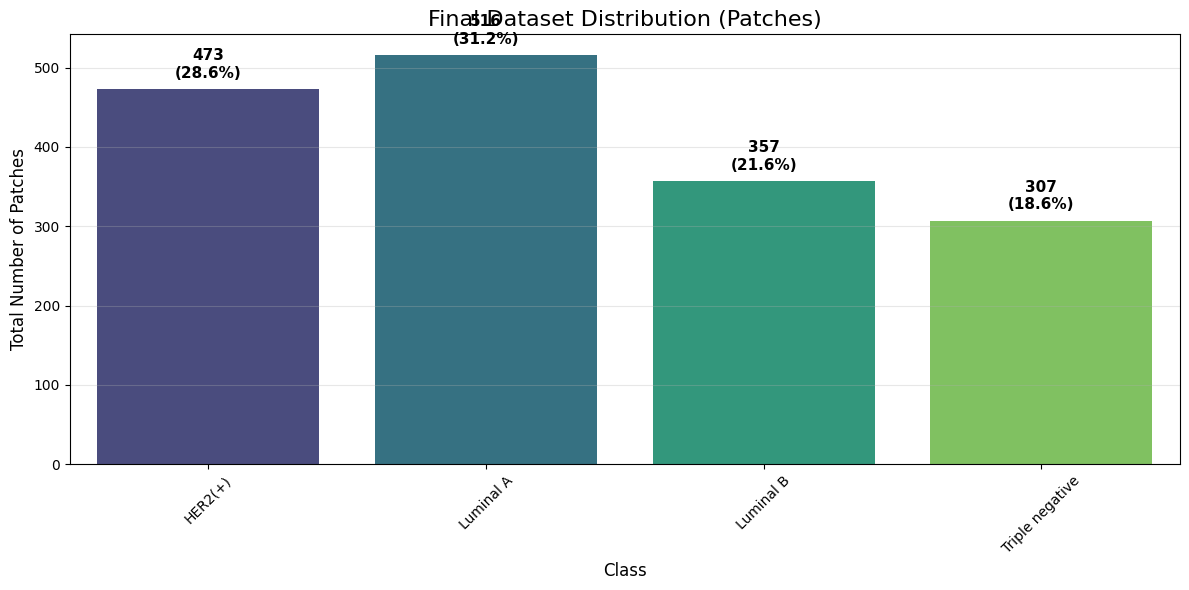

In [43]:
def plot_patch_distribution(labels, title="Final Dataset Distribution (Patches)"):

    # 1. Count classes
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # 2. Setup Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=unique_labels, y=counts, palette='viridis', hue=unique_labels, legend=False)
    
    # 3. Styling
    plt.title(title, fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Total Number of Patches", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # 4. Add count labels on top of bars
    total_patches = sum(counts)
    for i, v in enumerate(counts):
        percentage = (v / total_patches) * 100
        ax.text(i, v + (max(counts)*0.02), f"{v}\n({percentage:.1f}%)", 
                ha='center', va='bottom', fontweight='bold', fontsize=11)
        
    plt.tight_layout()
    plt.show()

# Run the plot on the generated labels
print(f"Visualizing distribution of {len(train_labels_multi)} generated patches...")
plot_patch_distribution(train_labels_multi)

## Cross Entropy

In [44]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
CRITERION = nn.CrossEntropyLoss() # Standard CrossEntropy

## CNN Model

### Model Architecture

In [45]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

In [46]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet20(nn.Module):
    def __init__(self, num_classes=4, hidden_size=256, dropout_rate=0.5):
        super(ResNet20, self).__init__()
        self.in_planes = 16

        # Initial Conv (3 -> 16 channels)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- MLP CLASSIFIER HEAD (2 LAYERS) ---
        input_features = 64 * BasicBlock.expansion
        
        self.classifier_head = nn.Sequential(
            # LAYER 1: Projects from CNN features to hidden size
            nn.Linear(input_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # LAYER 2: Projects from hidden size to number of classes
            nn.Linear(hidden_size, num_classes)
        )

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(BasicBlock(self.in_planes, planes, stride))
            self.in_planes = planes * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        
        # Pass through the 2-layer MLP head
        out = self.classifier_head(out)
        return out

### GradCam

In [47]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the layer to capture gradients and activations
        # We use a weakref to avoid memory leaks or issues with deepcopy if needed
        self.handles = []
        self.handles.append(target_layer.register_forward_hook(self.save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, x, class_idx=None):
        # 1. Forward Pass
        self.model.eval()
        
        # Zero grads before starting
        self.model.zero_grad()
        
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
            
        # 2. Backward Pass
        score = logits[:, class_idx].squeeze()
        score.backward(retain_graph=True)
        
        # 3. Generate Map
        # Pool the gradients across the channels
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations by the gradients
        # The activation map is usually (1, C, H, W)
        activation = self.activations[0]
        
        # Vectorized weighting is faster
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]
            
        # Average the channels to get a 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        
        # ReLU on top (we only care about positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, logits

In [48]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import cv2
import torch
import torch.nn as nn

def find_last_conv_layer(model):
    """
    Dynamically finds the last suitable layer for Grad-CAM.
    Priority:
    1. Last layer of 'layer4' (ResNet18/34/50/101/152)
    2. Last layer of 'layer3' (ResNet20, or smaller ResNets)
    3. Last layer of 'features' (VGG, AlexNet, DenseNet)
    4. Fallback: The very last nn.Conv2d module defined in the model.
    """
    # 1. Standard ResNet Convention (ImageNet)
    if hasattr(model, 'layer4') and len(model.layer4) > 0:
        return model.layer4[-1]

    # 2. CIFAR ResNet Convention (ResNet20, ResNet32, etc.)
    if hasattr(model, 'layer3') and len(model.layer3) > 0:
        return model.layer3[-1]

    # 3. VGG / DenseNet / SqueezeNet Convention
    if hasattr(model, 'features'):
        # iterate backwards to find a conv/block
        for layer in reversed(model.features):
            if isinstance(layer, (nn.Conv2d, nn.BatchNorm2d, nn.ReLU)):
                return layer

    # 4. Generic Fallback: Find the last Conv2d in the whole model
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    
    if last_conv is not None:
        return last_conv
        
    raise ValueError("Could not automatically find a target layer for Grad-CAM. Model has no recognized layers or Conv2d.")

def visualize_gradcam_with_mask_and_legend(model, images_tensor, masks_numpy, device, num_samples=3):
    """
    Plots: Original | Heatmap | GradCAM | Ground Truth Mask
    Model Invariant: Automatically detects the target layer.
    """
    model.eval()
    
    # Define Normalization (ImageNet standards)
    norm_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    norm_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

    # Handle case where dataset is smaller than requested samples
    if len(images_tensor) < num_samples: 
        num_samples = len(images_tensor)
    
    # Select random indices
    indices = np.random.choice(len(images_tensor), num_samples, replace=False)
    
    # Variables to store hook data
    gradients = None
    activations = None

    # Hook Functions
    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    # --- DYNAMIC LAYER SELECTION ---
    try:
        target_layer = find_last_conv_layer(model)
        # print(f"Grad-CAM Target Layer detected: {target_layer}")
    except ValueError as e:
        print(e)
        return

    # Ensure gradients are calculated
    for param in model.parameters():
        param.requires_grad_(True)
        
    # Register Hooks
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1: axes = [axes] 

    for i, idx in enumerate(indices):
        # 1. Prepare Input
        raw_tensor = images_tensor[idx].unsqueeze(0).to(device)
        input_tensor = (raw_tensor - norm_mean) / norm_std
        
        # Prepare visualization original (0-255 uint8)
        original_img = raw_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        # Clip just in case floating point errors take it slightly outside 0-1
        original_img = np.clip(original_img, 0, 1)
        original_img = (original_img * 255).astype(np.uint8).copy()
        
        # 2. Forward Pass
        model.zero_grad()
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        
        # 3. Backward Pass
        score = output[:, pred_idx]
        score.backward()
        
        # 4. Grad-CAM Calculation
        # Global Average Pooling on Gradients
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]).cpu()
        
        # Get activations
        act = activations.detach().cpu() # Shape: (1, C, H, W)
        
        # Weigh activations by gradients
        for j in range(act.shape[1]):
            act[:, j, :, :] *= pooled_gradients[j]
            
        # Average across channels to get heatmap
        heatmap = torch.mean(act, dim=1).squeeze()
        
        # Force float32 to avoid cv2 type errors
        heatmap = heatmap.numpy().astype(np.float32)
        
        # ReLU (Keep only positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize Heatmap
        if np.max(heatmap) != 0: 
            heatmap /= np.max(heatmap)
            
        # Resize Heatmap to Image Size
        heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        
        # Colorize
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        # Superimpose
        superimposed_img = heatmap_color * 0.4 + original_img * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # 5. Mask Overlay Logic
        mask_overlay = original_img.copy()
        if masks_numpy is not None:
            gt_mask = masks_numpy[idx]
            # Handle (H, W, 1) or (H, W) shapes
            if gt_mask.ndim == 3: gt_mask = gt_mask[:, :, 0]
            mask_bool = gt_mask > 0 
            
            green_color = np.array([0, 255, 0], dtype=np.uint8)
            if np.any(mask_bool):
                source_pixels = original_img[mask_bool].astype(np.float32)
                target_pixels = np.full_like(source_pixels, green_color)
                blended_pixels = (source_pixels * 0.7) + (target_pixels * 0.3)
                mask_overlay[mask_bool] = blended_pixels.astype(np.uint8)

        # 6. Plotting
        # Image
        axes[i][0].imshow(original_img)
        axes[i][0].set_title(f"Original\nSample {idx}")
        axes[i][0].axis('off')
        
        # Heatmap
        axes[i][1].imshow(heatmap_color)
        axes[i][1].set_title("Activation Heatmap")
        axes[i][1].axis('off')
        
        # Overlay
        axes[i][2].imshow(superimposed_img)
        axes[i][2].set_title(f"GradCAM (Pred: {pred_idx})")
        axes[i][2].axis('off')

        # Mask
        axes[i][3].imshow(mask_overlay)
        axes[i][3].set_title("Ground Truth Mask\n(Green Area)")
        axes[i][3].axis('off')

    # Colorbar layout
    plt.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    norm = plt.Normalize(vmin=0, vmax=1)
    sm = cm.ScalarMappable(cmap=cm.jet, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Medium', 'High'])
    
    # Clean up hooks
    handle_f.remove()
    handle_b.remove()
    plt.show()

### Data Augmentation

In [49]:
from torchvision import transforms

norm_mean = [0.485, 0.456, 0.406]
norm_std  = [0.229, 0.224, 0.225]

# --- TRANSFORMS PIPELINE: SIMPLE, OBVIOUS AUGS ---

train_transforms = transforms.Compose([
    # Geometric
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),

    # Intensity scaling to model expectations
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

# For val/test: no augmentation, only normalization
val_transforms = transforms.Compose([
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

test_transforms = transforms.Compose([
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

# 1. SETUP: Define a transform that Fixes Color but DOES NOT Normalize
# (Because visualize_gradcam does normalization internally)
vis_transforms = transforms.Compose([
    
])


print("Transforms Initialized. Using flips + small rotation + Normalize.")


Transforms Initialized. Using flips + small rotation + Normalize.


### Training epoch

In [50]:
# ---------------------------------------------------------
# MIL TRAINING: LOSS & F1 AT IMAGE LEVEL
# ---------------------------------------------------------
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    train_loader yields:
      inputs: (B, N_PATCHES_PER_IMAGE, C, H, W) in [0,1]
      targets: (B,) image-level labels
    """
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # inputs: (B, K, C, H, W)
        inputs = inputs.to(device)  # still [0,1]
        targets = targets.to(device)

        B, K, C, H, W = inputs.shape
        # Flatten patches into batch dimension for transforms and model
        inputs_flat = inputs.view(B * K, C, H, W)

        # --- APPLY AUGMENTATION + NORMALIZATION PER PATCH ---
        inputs_flat = train_transforms(inputs_flat)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits_patches = model(inputs_flat)             # (B*K, num_classes)
            logits_patches = logits_patches.view(B, K, -1)  # (B, K, num_classes)

            # Simple MIL aggregation: mean over patches -> image-level logits
            logits_imgs = logits_patches.mean(dim=1)        # (B, num_classes)

            loss = criterion(logits_imgs, targets)

            # Optional regularization
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * B

        predictions = logits_imgs.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    # Macro F1 is usually more relevant for medical multiclass
    epoch_f1 = f1_score(np.concatenate(all_targets),
                        np.concatenate(all_predictions),
                        average='macro')

    return epoch_loss, epoch_f1



### Validating epoch

In [51]:

def validate_one_epoch(model, val_loader, criterion, device):
    """
    val_loader yields:
      inputs: (B, N_PATCHES_PER_IMAGE, C, H, W) in [0,1]
      targets: (B,) image-level labels
    """
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            B, K, C, H, W = inputs.shape
            inputs_flat = inputs.view(B * K, C, H, W)

            # --- APPLY NORMALIZATION ONLY PER PATCH ---
            inputs_flat = val_transforms(inputs_flat)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits_patches = model(inputs_flat)           # (B*K, num_classes)
                logits_patches = logits_patches.view(B, K, -1)
                logits_imgs = logits_patches.mean(dim=1)      # (B, num_classes)

                loss = criterion(logits_imgs, targets)

            running_loss += loss.item() * B
            predictions = logits_imgs.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets),
                        np.concatenate(all_predictions),
                        average='macro')

    return epoch_loss, epoch_f1


In [52]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

### Training

In [53]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# ------------------------------
# CONFIG
# ------------------------------
NUM_CLASSES = 4  # set this as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Flag to enable/disable custom MLP classifier
USE_MLP_HEAD = False  # True -> use bottleneck MLP, False -> use default MobileNet head

# ------------------------------
# SMALL UTILITY: PARAM COUNTER
# ------------------------------
def print_param_stats(model, prefix=""):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if prefix:
        prefix = prefix + " "
    print(
        f"{prefix}Trainable Parameters: {trainable:,} / {total:,} "
        f"({trainable / total * 100:.2f}% trainable)"
    )

# ------------------------------
# 1. LOAD PRETRAINED WEIGHTS (MobileNetV3-Small)
# ------------------------------
weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
vanilla_model = mobilenet_v3_small(weights=weights)

# ------------------------------
# 2. DEFINE / SELECT CLASSIFIER HEAD
# ------------------------------
if USE_MLP_HEAD:
    # MobileNetV3-Small classifier is typically:
    # [Linear(in -> 1024), Hardswish, Dropout, Linear(1024 -> 1000)]
    num_ftrs = vanilla_model.classifier[-1].in_features  # usually 1024

    vanilla_model.classifier = nn.Sequential(
        nn.Flatten(),
        # Layer 1: Compress -> 128
        nn.Linear(num_ftrs, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        # Layer 2: Bottleneck 128 -> 32
        nn.Linear(128, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(p=0.1),
        # Output Layer
        nn.Linear(32, NUM_CLASSES),
    )
    print("Using custom MLP classifier head.")
else:
    # Use the original MobileNet classifier but adjust output classes
    in_features = vanilla_model.classifier[-1].in_features
    vanilla_model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    num_ftrs = in_features
    print("Using simplified (modified default) MobileNetV3-Small classifier head.")

vanilla_model = vanilla_model.to(device)

# AMP scaler (disabled here, but kept for API compatibility)
scaler = torch.amp.GradScaler("cuda", enabled=False)

print(f"Initialized MobileNetV3-Small. Input Features: {num_ftrs}")
print_param_stats(vanilla_model, prefix="Initial")

# ---------------------------------------------------------
# PHASE 1: WARMUP (Head Only)
# ---------------------------------------------------------
print("\n=== PHASE 1: WARMUP (Frozen Backbone) ===")
print("Goal: Stabilize the classifier head weights.")

# Freeze EVERYTHING first
for param in vanilla_model.parameters():
    param.requires_grad = False

# Unfreeze Head
for param in vanilla_model.classifier.parameters():
    param.requires_grad = True

print_param_stats(vanilla_model, prefix="Warmup")

# High LR for the Head
optimizer_warmup = torch.optim.Adam(vanilla_model.classifier.parameters(), lr=1e-3)

# NOTE: assumes you already have:
# - train_loader
# - val_loader
# - CRITERION
# - fit(...)
best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader_mil,   # <-- image-level MIL loader
    val_loader=val_loader_mil,       # <-- image-level MIL loader
    epochs=20,
    criterion=CRITERION,
    optimizer=optimizer_warmup,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="mil_mobilenetv3_small",  # or whatever
    patience=5
)

# ---------------------------------------------------------
# PHASE 2: FINE-TUNING (Dynamic Selection)
# ---------------------------------------------------------
print("\n=== PHASE 2: FINE-TUNING ===")

# --- MAP FRIENDLY NAMES TO ACTUAL MODULES ---
# MobileNetV3-Small has `features` (backbone) and `classifier` (head).
layer_map = {
    "features":   vanilla_model.features,    # convolutional backbone
    "classifier": vanilla_model.classifier,  # head
}

# --- YOUR SELECTION ---
# For a small dataset, you can start with ["classifier"] and later try ["features", "classifier"].
layers_to_unfreeze = ["features", "classifier"]

# 1. Reset: Freeze EVERYTHING first
for param in vanilla_model.parameters():
    param.requires_grad = False

# 2. Loop through your selection and unfreeze
for name in layers_to_unfreeze:
    if name in layer_map:
        module = layer_map[name]
        for param in module.parameters():
            param.requires_grad = True
        print(f" -> Unfrozen: {name}")
    else:
        print(f" -> Warning: '{name}' is not a valid layer name.")

print_param_stats(vanilla_model, prefix="Fine-tune")

# 3. Setup Optimizer (Only for unfrozen parameters)
optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vanilla_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

# 4. Train
best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader_mil,   # <-- image-level MIL loader
    val_loader=val_loader_mil,       # <-- image-level MIL loader
    epochs=500,
    criterion=CRITERION,
    optimizer=optimizer_finetune,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="mil_mobilenetv3_small",  # or whatever
    patience=50
)


Using simplified (modified default) MobileNetV3-Small classifier head.
Initialized MobileNetV3-Small. Input Features: 1024
Initial Trainable Parameters: 1,521,956 / 1,521,956 (100.00% trainable)

=== PHASE 1: WARMUP (Frozen Backbone) ===
Goal: Stabilize the classifier head weights.
Warmup Trainable Parameters: 594,948 / 1,521,956 (39.09% trainable)
Training 20 epochs...
Epoch   1/20 | Train: Loss=1.5441, F1 Score=0.2169 | Val: Loss=1.3211, F1 Score=0.2098
Epoch   2/20 | Train: Loss=1.4177, F1 Score=0.2371 | Val: Loss=1.3176, F1 Score=0.1776
Epoch   3/20 | Train: Loss=1.3416, F1 Score=0.2644 | Val: Loss=1.3319, F1 Score=0.1189
Epoch   4/20 | Train: Loss=1.3105, F1 Score=0.3006 | Val: Loss=1.3465, F1 Score=0.1444
Epoch   5/20 | Train: Loss=1.3250, F1 Score=0.2597 | Val: Loss=1.3447, F1 Score=0.1949
Epoch   6/20 | Train: Loss=1.2982, F1 Score=0.3359 | Val: Loss=1.3646, F1 Score=0.1973
Early stopping triggered after 6 epochs.
Best model restored from epoch 1 with val_f1 0.2098

=== PHASE 2

#### Plot Results

Generating comprehensive evaluation plots (With Transforms)...


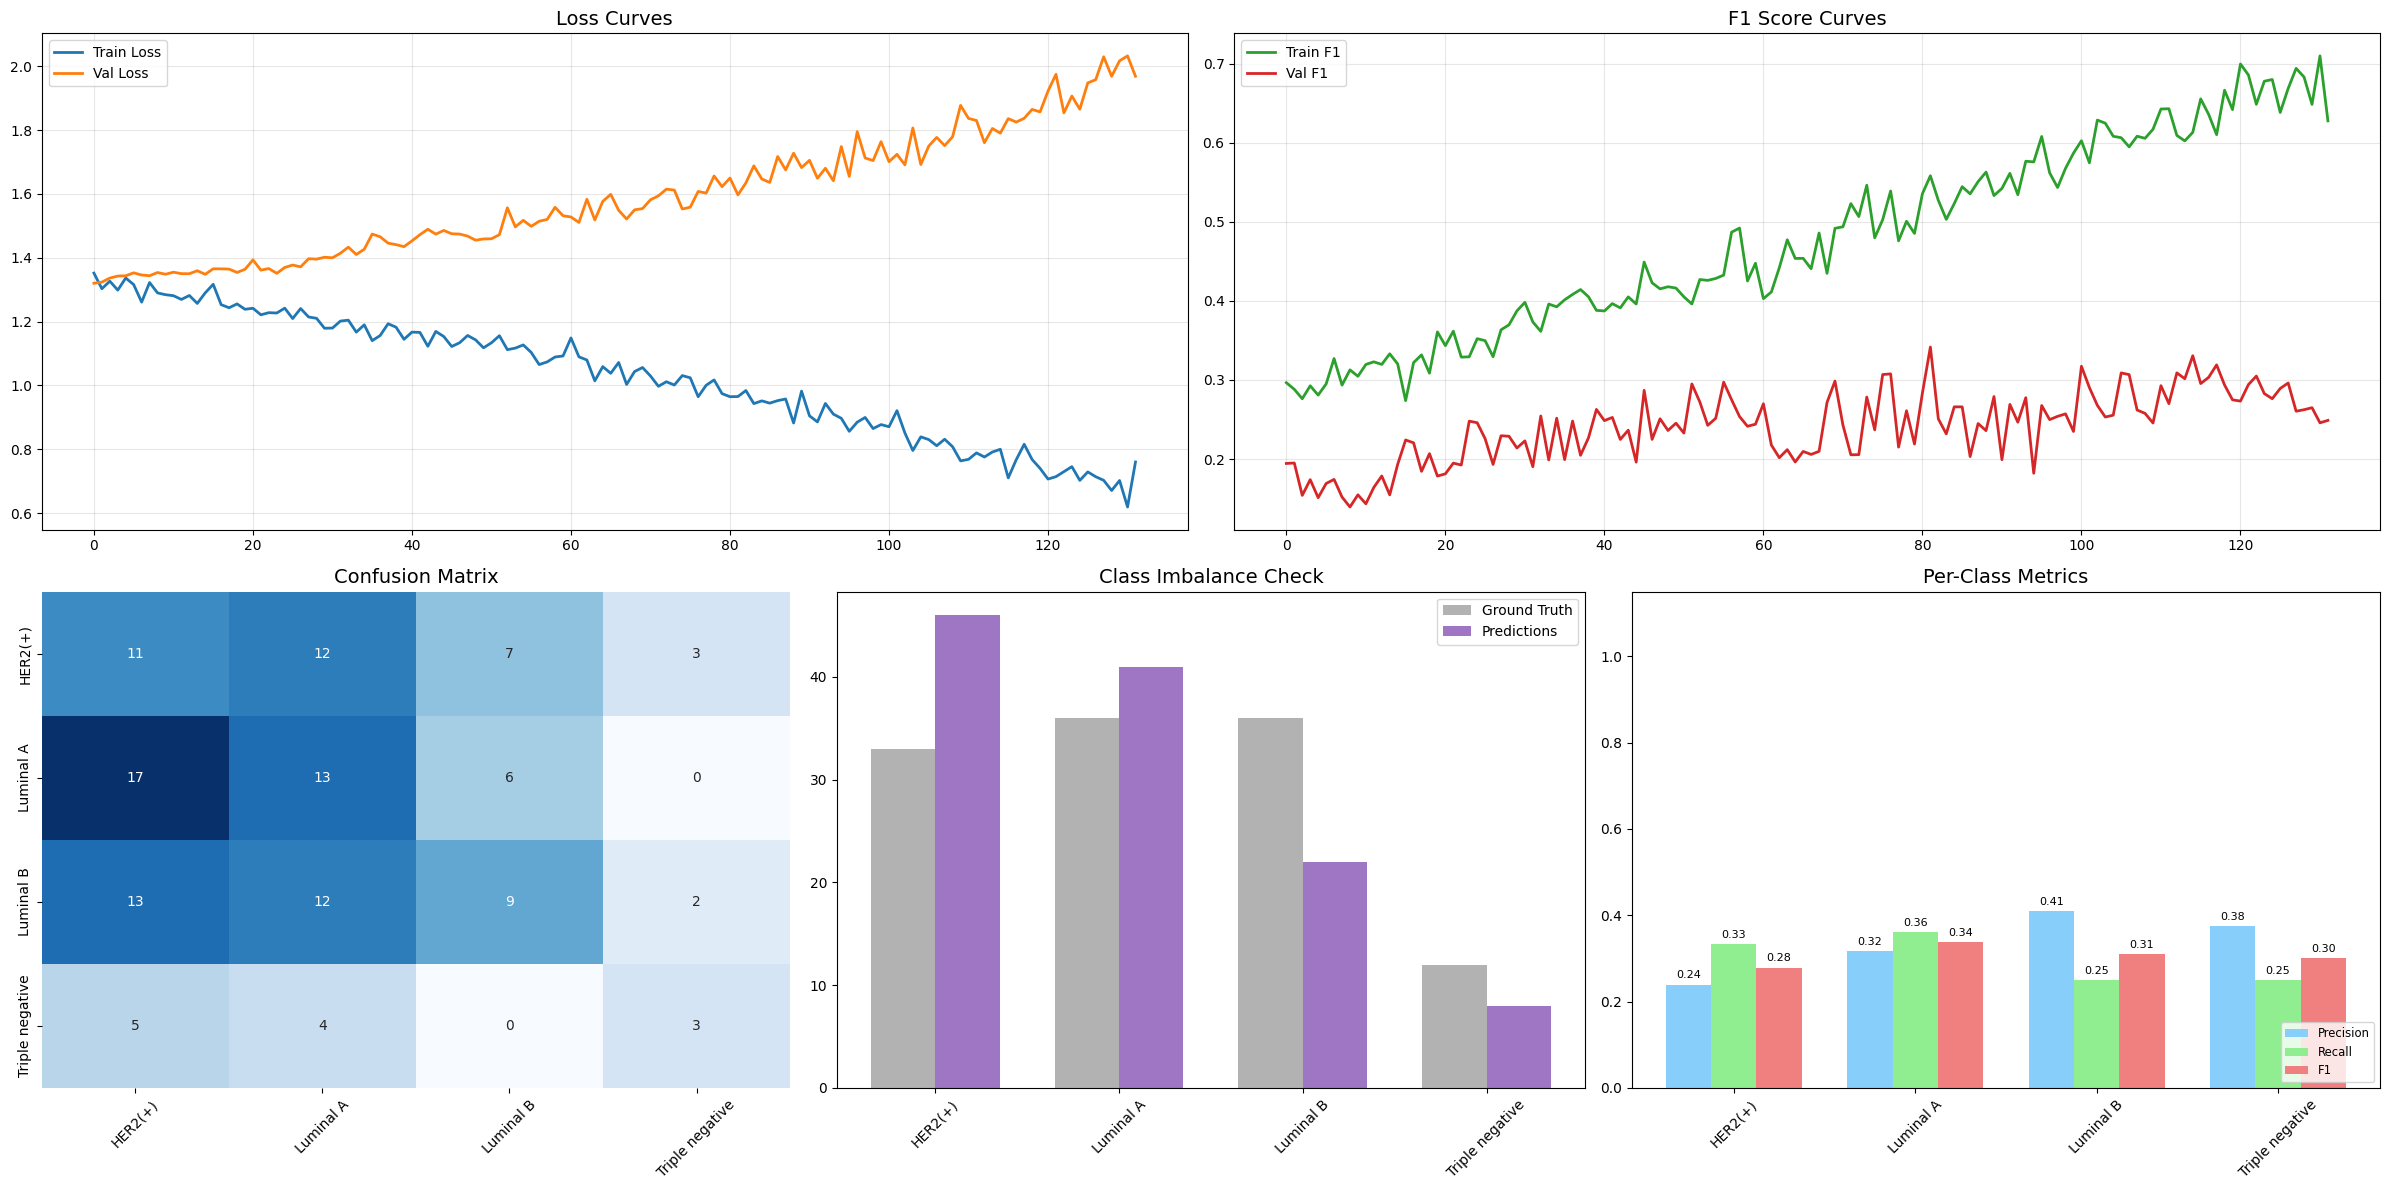

In [54]:
from sklearn.metrics import precision_recall_fscore_support

def plot_comprehensive_results(model, loader, device, label_encoder, history=None):
    """
    Plots:
    Row 1: Training History (Loss & F1)
    Row 2: Confusion Matrix | Class Distribution | Per-Class Metrics
    Works with:
      - MIL loader: inputs shape (B, K, C, H, W)
      - Standard loader: inputs shape (B, C, H, W)
    """
    print("Generating comprehensive evaluation plots (With Transforms)...")
    
    # --- 1. Get Predictions ---
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in loader:
            # Handle tuple (inputs, labels)
            inputs = batch[0].to(device)
            labels = batch[1].to(device)

            if inputs.ndim == 5:
                # MIL: (B, K, C, H, W)
                B, K, C, H, W = inputs.shape
                inputs_flat = inputs.view(B * K, C, H, W)

                # Apply validation transforms per patch
                inputs_flat = val_transforms(inputs_flat)

                # Forward pass on patches
                logits_patches = model(inputs_flat)              # (B*K, num_classes)
                logits_patches = logits_patches.view(B, K, -1)   # (B, K, num_classes)

                # Aggregate to image level (same as inference): max over patches
                outputs = logits_patches.max(dim=1).values       # (B, num_classes)
            else:
                # Non-MIL fallback: standard (B, C, H, W)
                inputs = val_transforms(inputs)
                outputs = model(inputs)

            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
            
    class_names = label_encoder.classes_
    
    # --- 2. Setup Figure Grid ---
    fig = plt.figure(figsize=(24, 12)) 
    gs = fig.add_gridspec(2, 6) 

    # =======================================================
    # ROW 1: HISTORY
    # =======================================================
    if history:
        ax1 = fig.add_subplot(gs[0, 0:3])
        ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
        ax1.plot(history['val_loss'], label='Val Loss', color='tab:orange', linewidth=2)
        ax1.set_title("Loss Curves", fontsize=14)
        ax1.legend(); ax1.grid(True, alpha=0.3)
        
        ax2 = fig.add_subplot(gs[0, 3:6])
        ax2.plot(history['train_f1'], label='Train F1', color='tab:green', linewidth=2)
        ax2.plot(history['val_f1'], label='Val F1', color='tab:red', linewidth=2)
        ax2.set_title("F1 Score Curves", fontsize=14)
        ax2.legend(); ax2.grid(True, alpha=0.3)
    else:
        ax1 = fig.add_subplot(gs[0, 0:3]); ax1.text(0.5, 0.5, "No History", ha='center')
        ax2 = fig.add_subplot(gs[0, 3:6]); ax2.text(0.5, 0.5, "No History", ha='center')

    # =======================================================
    # ROW 2: ANALYSIS
    # =======================================================
    
    # 1. Confusion Matrix
    ax3 = fig.add_subplot(gs[1, 0:2])
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax3, cbar=False)
    ax3.set_title("Confusion Matrix", fontsize=14)
    ax3.tick_params(axis='x', rotation=45)

    # 2. Prediction Distribution
    ax4 = fig.add_subplot(gs[1, 2:4])
    unique_true, true_counts = np.unique(all_targets, return_counts=True)
    pred_counts_full = np.zeros(len(class_names))
    unique_pred, pred_counts = np.unique(all_preds, return_counts=True)
    for cls, count in zip(unique_pred, pred_counts): 
        pred_counts_full[cls] = count
    
    true_counts_full = np.zeros(len(class_names))
    for cls, count in zip(unique_true, true_counts): 
        true_counts_full[cls] = count

    x = np.arange(len(class_names))
    width = 0.35
    ax4.bar(x - width/2, true_counts_full, width, label='Ground Truth', color='gray', alpha=0.6)
    ax4.bar(x + width/2, pred_counts_full, width, label='Predictions', color='tab:purple', alpha=0.9)
    ax4.set_title("Class Imbalance Check", fontsize=14)
    ax4.set_xticks(x); ax4.set_xticklabels(class_names, rotation=45)
    ax4.legend()

    # 3. Per-Class Metrics
    ax5 = fig.add_subplot(gs[1, 4:6])
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=range(len(class_names)), zero_division=0
    )
    
    x = np.arange(len(class_names))
    width = 0.25
    rects1 = ax5.bar(x - width, precision, width, label='Precision', color='#87CEFA')
    rects2 = ax5.bar(x, recall, width, label='Recall', color='#90EE90')
    rects3 = ax5.bar(x + width, f1, width, label='F1', color='#F08080')

    ax5.set_title('Per-Class Metrics', fontsize=14)
    ax5.set_xticks(x); ax5.set_xticklabels(class_names, rotation=45)
    ax5.legend(loc='lower right', fontsize='small')
    ax5.set_ylim(0, 1.15)
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0.01:
                ax5.annotate(f'{height:.2f}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(0, 3), textcoords="offset points",
                             ha='center', va='bottom', fontsize=8)
    autolabel(rects1); autolabel(rects2); autolabel(rects3)

    plt.tight_layout()
    plt.show()


plot_comprehensive_results(
    model=best_model,
    loader=val_loader_mil,
    device=device,
    label_encoder=label_encoder,
    history=history
)

--- GENERATING GRAD-CAM FOR VALIDATION SET (Consistency Check) ---
Selected indices: [534 866 171  81]


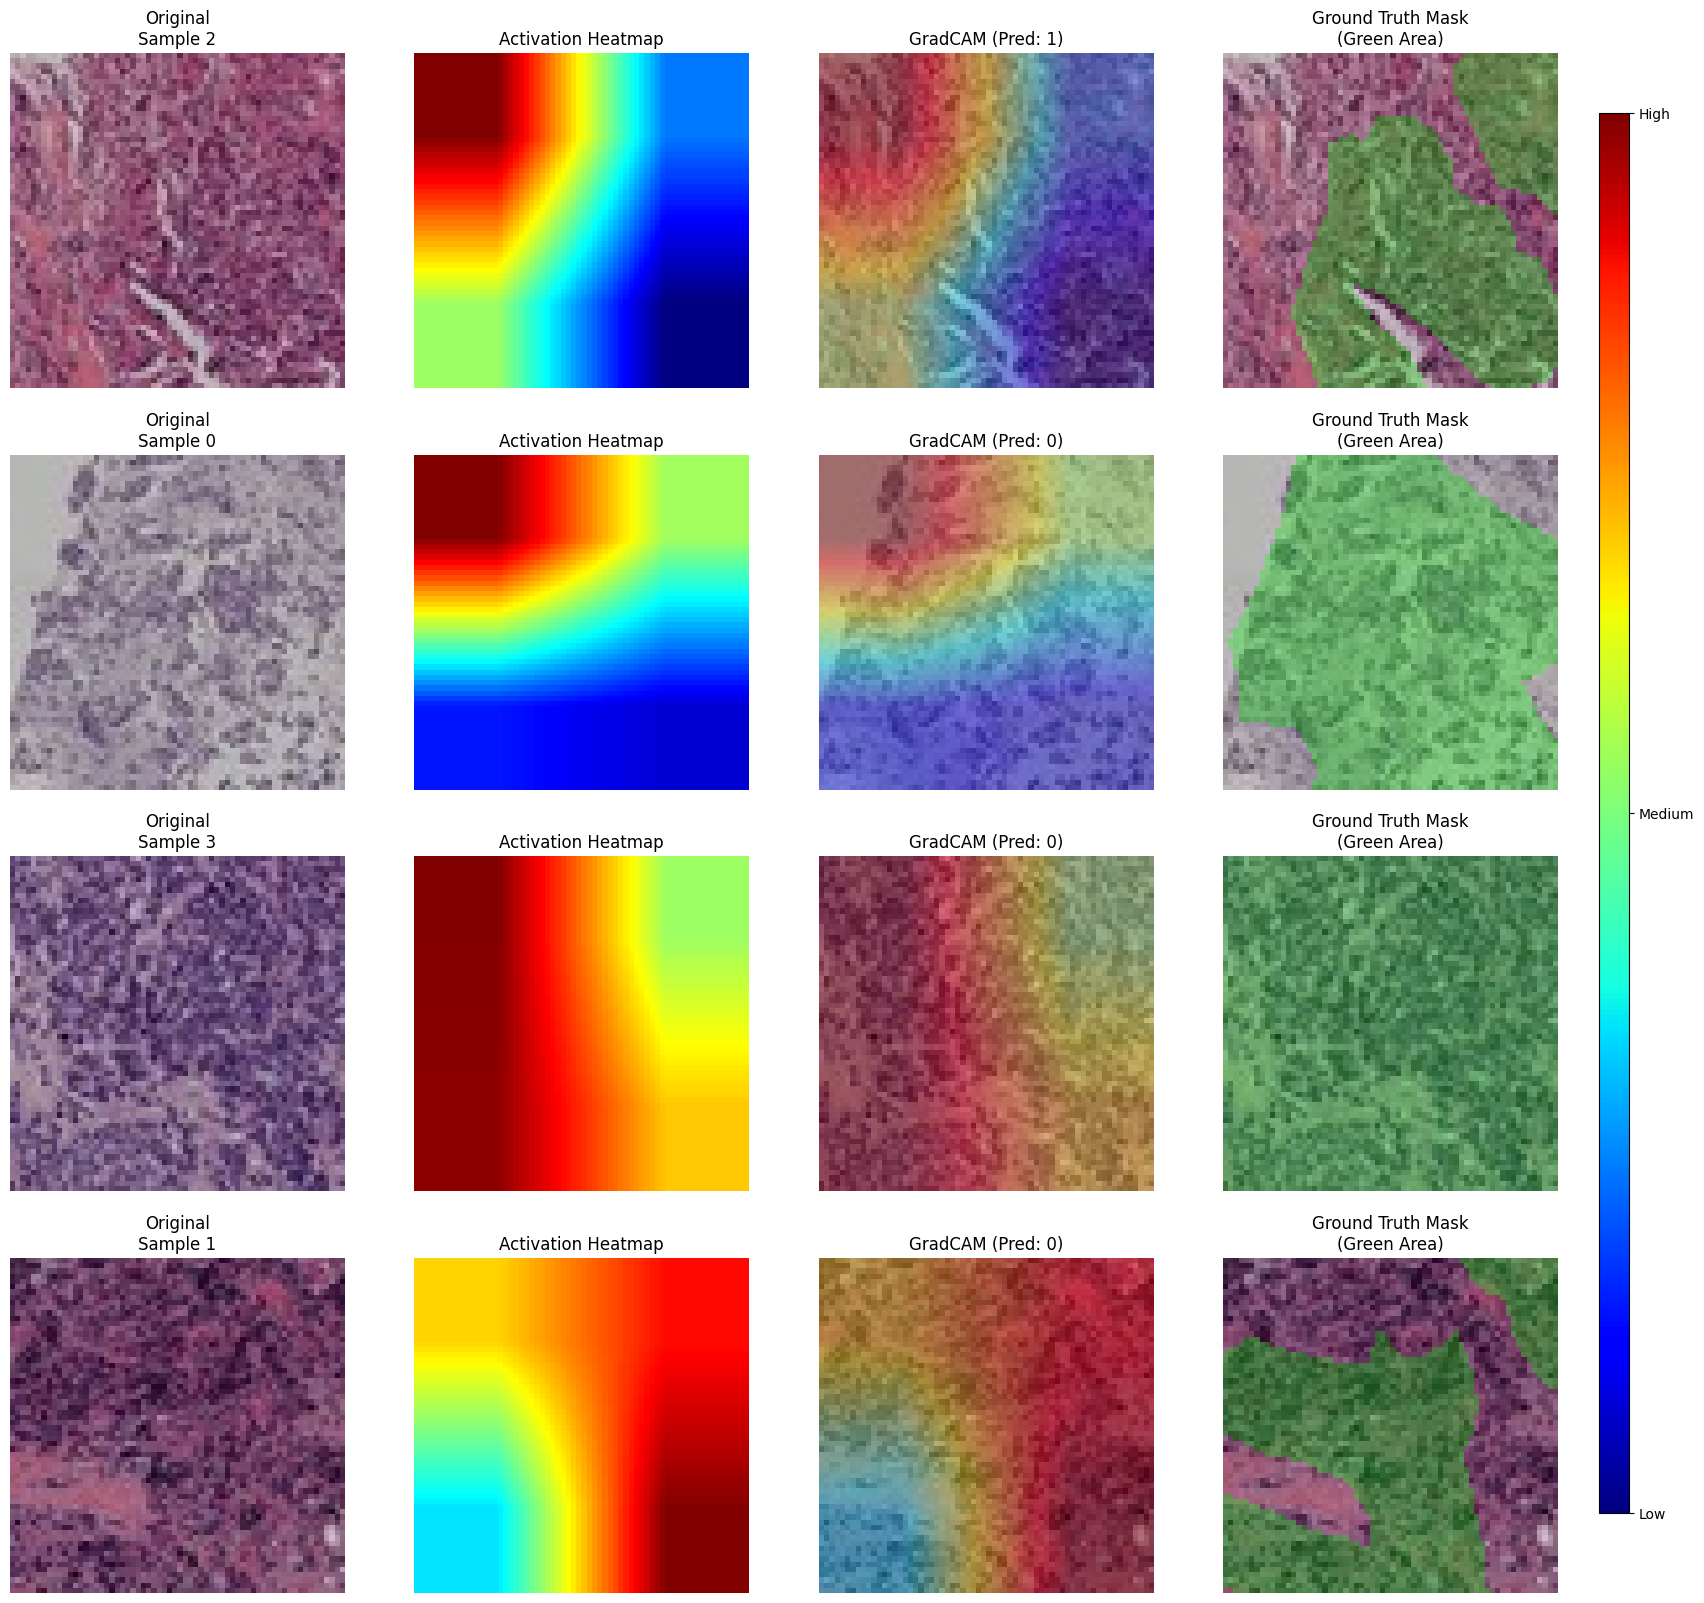

In [55]:
import cv2
import numpy as np
import torch
from torchvision import transforms

print("--- GENERATING GRAD-CAM FOR VALIDATION SET (Consistency Check) ---")



# 2. SELECT VALIDATION SAMPLES
# We use 'val_mask' to find indices in 'raw_train' that are actually validation data
if 'raw_train' in locals() and 'val_mask' in locals():
    # Get all indices that correspond to True in the validation mask
    val_indices = np.where(val_mask)[0]
    
    num_samples = 4
    # Pick random indices strictly from the validation set
    if len(val_indices) < num_samples:
        selected_indices = val_indices
    else:
        selected_indices = np.random.choice(val_indices, num_samples, replace=False)
    
    viz_images_list = []
    viz_masks_list = []

    print(f"Selected indices: {selected_indices}")

    for idx in selected_indices:
        # A. Get Raw Image from Training Array (which contains Val data)
        img_np = raw_train[idx] # (H, W, 3)
        
        # B. Convert to Tensor [0, 1]
        img_tensor = torch.from_numpy(img_np).float().permute(2, 0, 1) / 255.0
        
        # C. Apply HistoContrastFix (Turns it Pink/Purple)
        img_fixed = vis_transforms(img_tensor)
        viz_images_list.append(img_fixed)
        
        # D. Get Mask
        if 'train_masks' in locals():
            mask = train_masks[idx]
            if mask.shape[:2] != (INPUT_SIZE, INPUT_SIZE):
                mask = cv2.resize(mask, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_NEAREST)
            viz_masks_list.append(mask)
        else:
            viz_masks_list = None

    # 3. RUN GRAD-CAM
    viz_tensor = torch.stack(viz_images_list)
    viz_masks_arr = np.array(viz_masks_list) if viz_masks_list else None

    # Call visualization
    visualize_gradcam_with_mask_and_legend(
        model=best_model, 
        images_tensor=viz_tensor, 
        masks_numpy=viz_masks_arr, 
        device=device,
        num_samples=len(selected_indices)
    )

else:
    print("Error: 'raw_train' or 'val_mask' variables not found. Please re-run Data Loading.")

## Test Prediction

In [56]:
# %% [markdown]
# ## Test Prediction (image-level, per-slide)

# %%
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np

def generate_soft_voting_submission(model, 
                                    X_test_tensor,    # (N_patches, C, H, W) float32 in [0,1]
                                    patch_ids,        # list/array len N_patches (image IDs)
                                    device, 
                                    encoder, 
                                    batch_size=64,
                                    output_file="submission.csv"):
    """
    Image-level prediction from patch model:

      - model: patch-level network (takes (B, C, H, W))
      - X_test_tensor: all test patches stacked
      - patch_ids: image ID for each patch (same order as X_test_tensor)
      - Aggregation: max over patch logits per image, then softmax + argmax.
    """
    print("--- Running image-level inference (patch logits -> per-image predictions) ---")

    model.eval()
    all_patch_logits = []
    N = X_test_tensor.shape[0]

    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = X_test_tensor[start:end].to(device)   # (B, C, H, W)

            # test-time transforms (e.g., normalization only)
            batch = test_transforms(batch)

            logits = model(batch)  # (B, num_classes)
            all_patch_logits.append(logits.cpu().numpy())

    # Stack all patch logits
    logits_matrix = np.concatenate(all_patch_logits, axis=0)  # (N_patches, num_classes)

    if logits_matrix.shape[0] != len(patch_ids):
        raise ValueError(f"Mismatch! {logits_matrix.shape[0]} logits vs {len(patch_ids)} patch IDs.")

    num_classes = logits_matrix.shape[1]
    logit_cols = [f'logit_{i}' for i in range(num_classes)]

    # One row per patch
    df_patches = pd.DataFrame(logits_matrix, columns=logit_cols)
    df_patches['image_id'] = patch_ids
    df_patches['image_id'] = df_patches['image_id'].astype(str)

    # ---- Per-image aggregation: max logits over patches (MIL-style) ----
    df_logits_img = df_patches.groupby('image_id')[logit_cols].max()

    # Softmax at image level
    image_logits = df_logits_img.values  # (N_images, num_classes)
    image_probs = F.softmax(torch.from_numpy(image_logits), dim=1).numpy()
    final_class_indices = np.argmax(image_probs, axis=1)

    # Build final DataFrame
    final_preds = pd.DataFrame({
        'image_id': df_logits_img.index,
        'prediction': final_class_indices
    })

    # Decode labels
    final_preds['label'] = encoder.inverse_transform(final_preds['prediction'].astype(int))
    final_preds['sample_index'] = final_preds['image_id'].apply(lambda x: f"img_{x}.png")

    submission_df = final_preds[['sample_index', 'label']].copy()
    submission_df['sort_key'] = submission_df['sample_index'].str.extract(r'(\d+)').astype(int)
    submission_df = submission_df.sort_values('sort_key').drop(columns=['sort_key'])

    submission_df.to_csv(output_file, index=False)
    print(f"Saved aggregated submission to '{output_file}'")
    print(f"Total Unique Images: {len(submission_df)}")
    print(submission_df.head())

    return submission_df

# --- RUN IT ---
submission_df = generate_soft_voting_submission(
    model=best_model,
    X_test_tensor=X_test_tensor,
    patch_ids=test_ids_patches,
    device=device,
    encoder=label_encoder,
    batch_size=64,
    output_file="submission.csv"
)


--- Running image-level inference (patch logits -> per-image predictions) ---
Saved aggregated submission to 'submission.csv'
Total Unique Images: 477
   sample_index            label
0  img_0000.png  Triple negative
1  img_0001.png        Luminal B
2  img_0002.png        Luminal A
3  img_0003.png        Luminal A
4  img_0004.png        Luminal A


--- GENERATING GRAD-CAM (With HistoContrastFix) ---


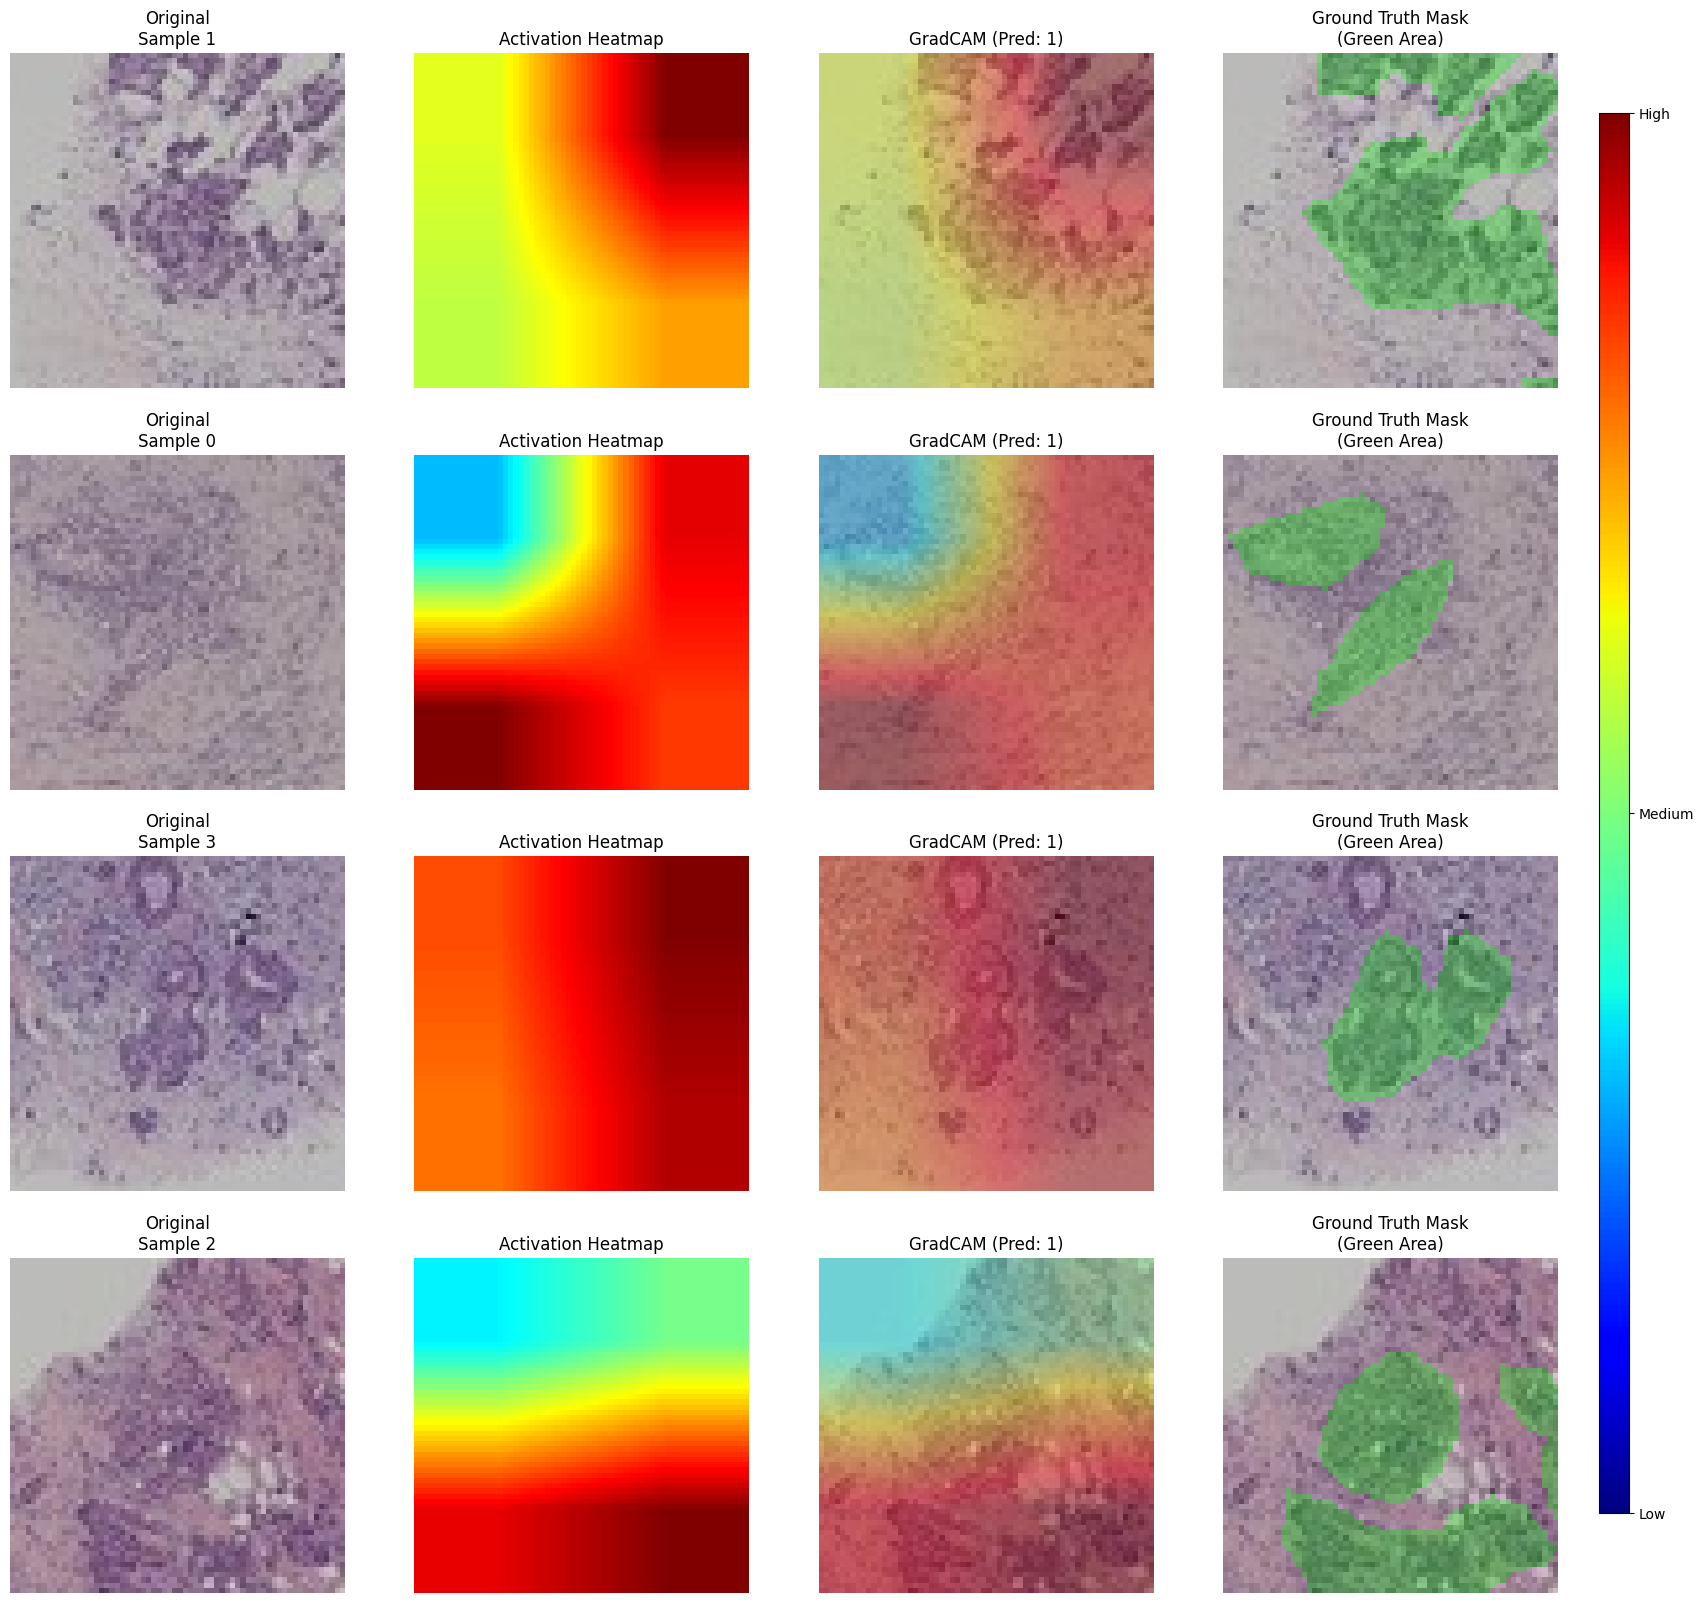

In [57]:
import cv2
import numpy as np
import torch
from torchvision import transforms

print("--- GENERATING GRAD-CAM (With HistoContrastFix) ---")



# 2. SELECT SAMPLES
# We grab random indices from the raw test set you loaded earlier
num_samples = 4
if 'raw_test' in locals():
    indices = np.random.choice(len(raw_test), num_samples, replace=False)
    
    viz_images_list = []
    viz_masks_list = []

    for idx in indices:
        # A. Get Raw Image (Muddy, uint8)
        img_np = raw_test[idx] # (H, W, 3)
        
        # B. Convert to Tensor [0, 1]
        img_tensor = torch.from_numpy(img_np).float().permute(2, 0, 1) / 255.0
        
        # C. Apply HistoContrastFix (Turns it Pink/Purple)
        # Result is (3, 128, 128) in range [0, 1]
        img_fixed = vis_transforms(img_tensor)
        viz_images_list.append(img_fixed)
        
        # D. Get Mask & Resize to 128 (to match image)
        if 'test_masks' in locals():
            mask = test_masks[idx]
            if mask.shape[:2] != (INPUT_SIZE, INPUT_SIZE):
                mask = cv2.resize(mask, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_NEAREST)
            viz_masks_list.append(mask)
        else:
            viz_masks_list = None

    # 3. RUN GRAD-CAM
    # Stack images into a batch tensor
    viz_tensor = torch.stack(viz_images_list)
    viz_masks_arr = np.array(viz_masks_list) if viz_masks_list else None

    # Call your existing function
    visualize_gradcam_with_mask_and_legend(
        model=best_model, 
        images_tensor=viz_tensor, # Pink/Purple images (0-1)
        masks_numpy=viz_masks_arr, 
        device=device,
        num_samples=num_samples
    )

else:
    print("Error: 'raw_test' variable not found. Please re-run the Data Loading cell.")


Checking Prediction Balance...


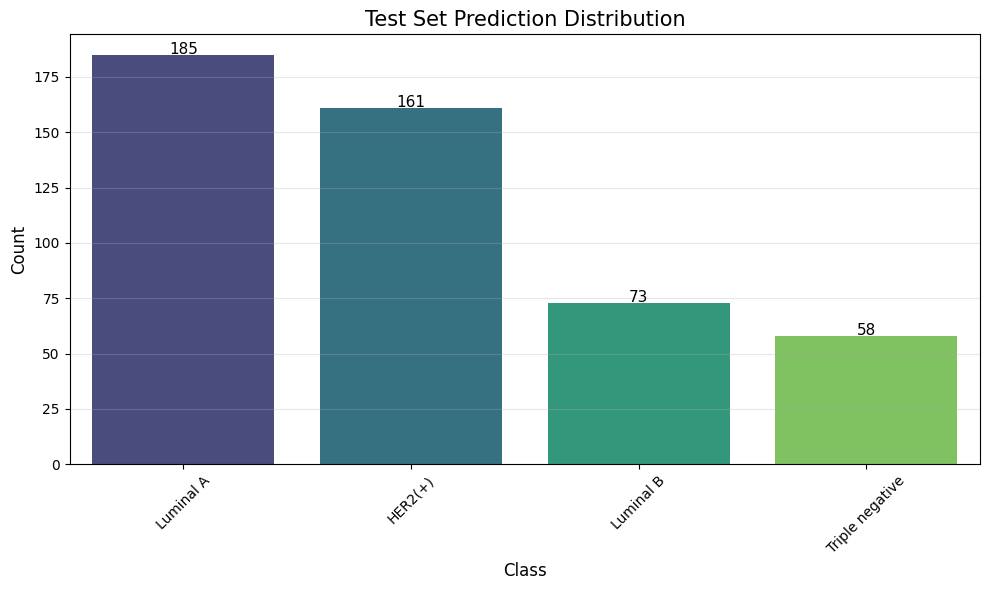

In [58]:
def plot_test_distribution(submission_df):
    plt.figure(figsize=(10, 6))
    
    # Count the predicted labels
    counts = submission_df['label'].value_counts()
    
    # Plot bar chart
    ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)
    
    plt.title("Test Set Prediction Distribution", fontsize=15)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Add numbers on top of bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
        
    plt.tight_layout()
    plt.show()
print("\nChecking Prediction Balance...")
plot_test_distribution(submission_df)